In [1]:
# -----------------------------------------------------------------------
# Config: reads param.in to locate data and plots directories.
# Edit PARAM_FILE if your param.in lives elsewhere.
# -----------------------------------------------------------------------
import shlex
from pathlib import Path

PARAM_FILE = Path("param.in")   # adjust if needed

_defaults = {"output_dir": "programs/data", "output_name": "dtrimp_results", "model": "1"}
_cfg = dict(_defaults)

if PARAM_FILE.exists():
    tokens = shlex.split(PARAM_FILE.read_text())
    _it = iter(tokens)
    for tok in _it:
        if tok in ("--output_dir", "--output_name", "--model"):
            _cfg[tok.lstrip("-")] = next(_it)
        # flags without value that could confuse the parser are skipped automatically
else:
    print(f"WARNING: {PARAM_FILE} not found — using defaults")

data_dir  = Path(_cfg["output_dir"])
plots_dir = data_dir / "plots"
model     = int(_cfg["model"])

print(f"model      = {model}")
print(f"data_dir   = {data_dir}")
print(f"plots_dir  = {plots_dir}")


model      = 2
data_dir   = data/Mickey2
plots_dir  = data/Mickey2/plots


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

def load_dat(filepath):
    data = np.loadtxt(filepath)
    return data[:, 0], data[:, 1], data[:, 2]  # t, Re, Im

def plot_gf(ax_re, ax_im, dat_files, data_dir, colors, linestyles, ylabel="G(t,0)"):
    for label, filename in dat_files.items():
        filepath = data_dir / filename
        if filepath.exists():
            t, Re, Im = load_dat(filepath)
            ax_re.plot(t, Re, color=colors[label], linestyle=linestyles[label], lw=2, label=label)
            ax_im.plot(t, Im, color=colors[label], linestyle=linestyles[label], lw=2, label=label)
        else:
            print(f"File not found: {filepath}")
    for ax, part in [(ax_re, "Re"), (ax_im, "Im")]:
        ax.set_xlabel("t", fontsize=12)
        ax.set_ylabel(f"{part} {ylabel}", fontsize=12)
        ax.set_title(f"{part} {ylabel}", fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)


# Model 1

In [9]:
if model == 1:

    # lesser / greater datasets
    components = {
        "Lesser": {
            "suffix": "",
            "kcomp": "FB",
        },
        "Greater": {
            "suffix": "_greater",
            "kcomp": "BF",
        },
    }

    colors = {
        "G_ref":      "tab:blue",
        "G_sys":      "tab:red",
        "G_DTRILEX":  "tab:green",
        "G_cpt":      "tab:purple",
    }

    linestyles = {
        "G_ref":      "--",
        "G_sys":      "-",
        "G_DTRILEX":  "-.",
        "G_cpt":      ":",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Model 1 — Green's functions G(t,0)")

    for row, (comp_name, comp_info) in enumerate(components.items()):

        suffix = comp_info["suffix"]
        kcomp  = comp_info["kcomp"]

        dat_files = {
            "G_ref":      f"G_ref{suffix}.dat",
            "G_sys":      f"G_sys{suffix}.dat",
            "G_DTRILEX":  f"G_Dtrilex{suffix}.dat",
            "G_cpt":      f"G_cpt{suffix}.dat",
        }

        ax_re = axes[row, 0]
        ax_im = axes[row, 1]

        plot_gf(
            ax_re,
            ax_im,
            dat_files,
            data_dir,
            colors,
            linestyles
        )

        ax_re.set_title(f"{comp_name} — Re G(t,0) [{kcomp}]")
        ax_im.set_title(f"{comp_name} — Im G(t,0) [{kcomp}]")

    plt.tight_layout()

    plots_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        plots_dir / "M1_G_2x2.png",
        dpi=150
    )

    plt.show()

else:
    print("Skipping Model 1 G plot (model != 1)")

Skipping Model 1 G plot (model != 1)


In [10]:
if model == 1:

    # lesser / greater datasets
    components = {
        "Lesser": {
            "suffix": "",
            "kcomp": "FB",
        },
        "Greater": {
            "suffix": "_greater",
            "kcomp": "BF",
        },
    }

    colors = {
        "Sigma_DTRILEX": "tab:blue",
    }

    linestyles = {
        "Sigma_DTRILEX": "-",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(r"Model 1 — Self-energy $\Sigma(t,0)$")

    for row, (comp_name, comp_info) in enumerate(components.items()):

        suffix = comp_info["suffix"]
        kcomp  = comp_info["kcomp"]

        dat_files = {
            "Sigma_DTRILEX": f"Sigma_Dtrilex{suffix}.dat",
        }

        ax_re = axes[row, 0]
        ax_im = axes[row, 1]

        plot_gf(
            ax_re,
            ax_im,
            dat_files,
            data_dir,
            colors,
            linestyles,
            ylabel="Σ(t,0)"
        )

        ax_re.set_title(
            rf"{comp_name} — Re $\Sigma(t,0)$ [{kcomp}]"
        )

        ax_im.set_title(
            rf"{comp_name} — Im $\Sigma(t,0)$ [{kcomp}]"
        )

    plt.tight_layout()

    plots_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        plots_dir / "M1_Sigma_2x2.png",
        dpi=150
    )

    plt.show()

else:
    print("Skipping Model 1 Σ plot (model != 1)")

Skipping Model 1 Σ plot (model != 1)


# Model 2

## Parallel

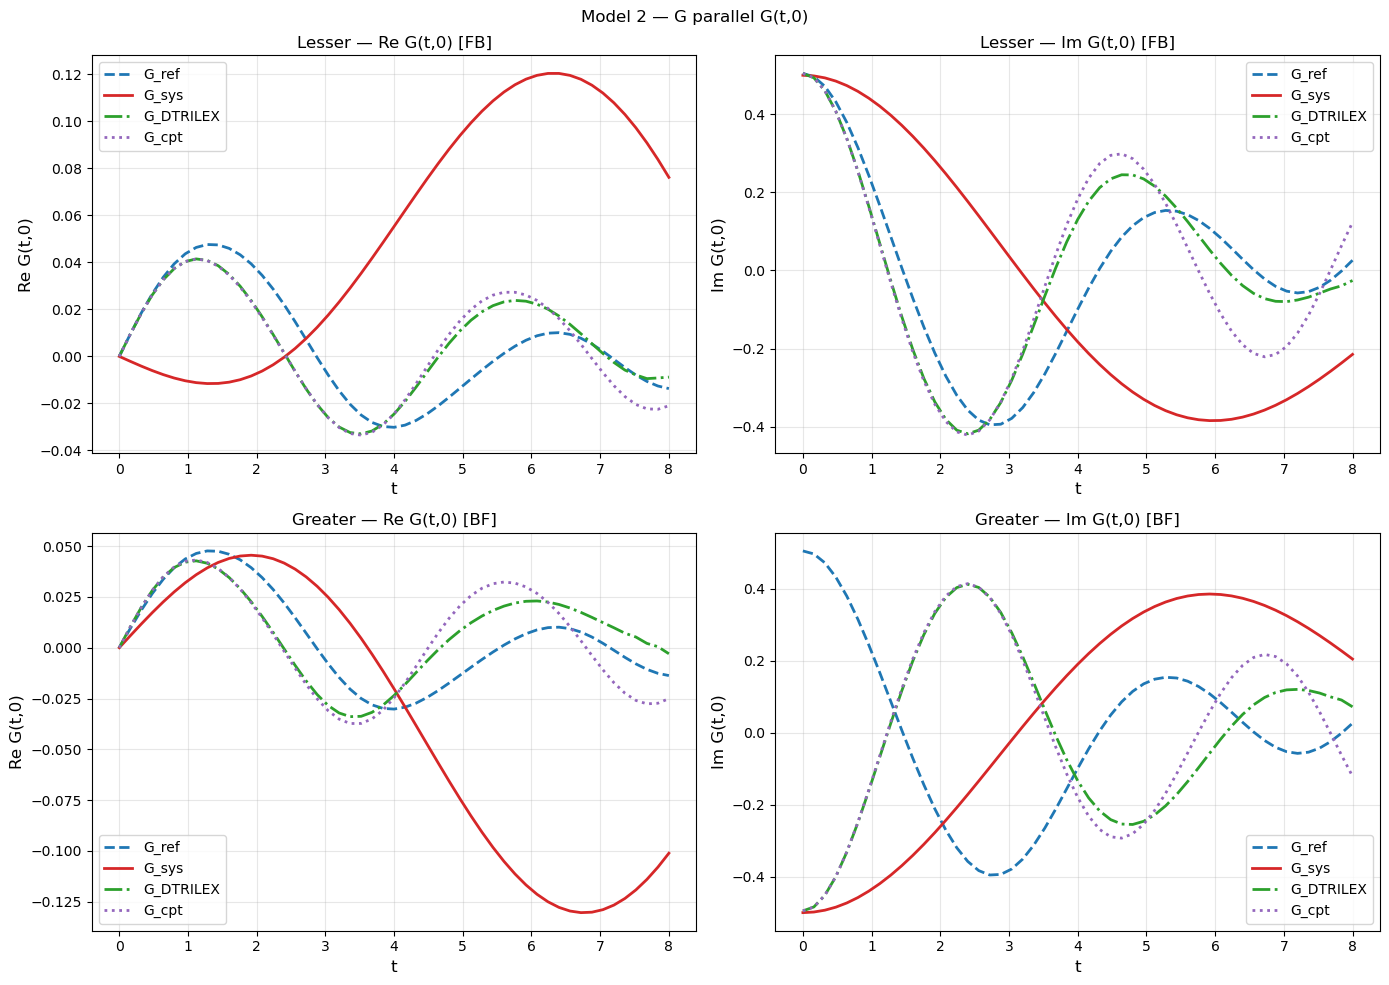

In [13]:
if model == 2:

    # lesser / greater datasets
    components = {
        "Lesser": {
            "suffix": "_par",
            "kcomp": "FB",
        },
        "Greater": {
            "suffix": "_par_greater",
            "kcomp": "BF",
        },
    }

    colors = {
        "G_ref":      "tab:blue",
        "G_sys":      "tab:red",
        "G_DTRILEX":  "tab:green",
        "G_cpt":      "tab:purple",
    }

    linestyles = {
        "G_ref":      "--",
        "G_sys":      "-",
        "G_DTRILEX":  "-.",
        "G_cpt":      ":",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Model 2 — G parallel G(t,0)")

    for row, (comp_name, comp_info) in enumerate(components.items()):

        suffix = comp_info["suffix"]
        kcomp  = comp_info["kcomp"]

        dat_files = {
            "G_ref":      "G_ref.dat",
            "G_sys":      f"G_sys{suffix}.dat",
            "G_DTRILEX":  f"G_Dtrilex{suffix}.dat",
            "G_cpt":      f"G_cpt{suffix}.dat",
        }

        ax_re = axes[row, 0]
        ax_im = axes[row, 1]

        plot_gf(
            ax_re,
            ax_im,
            dat_files,
            data_dir,
            colors,
            linestyles
        )

        ax_re.set_title(
            f"{comp_name} — Re G(t,0) [{kcomp}]"
        )

        ax_im.set_title(
            f"{comp_name} — Im G(t,0) [{kcomp}]"
        )

    plt.tight_layout()

    plots_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        plots_dir / "M2_G_par_2x2.png",
        dpi=150
    )

    plt.show()

else:
    print("Skipping Model 2 G‖ plot (model != 2)")

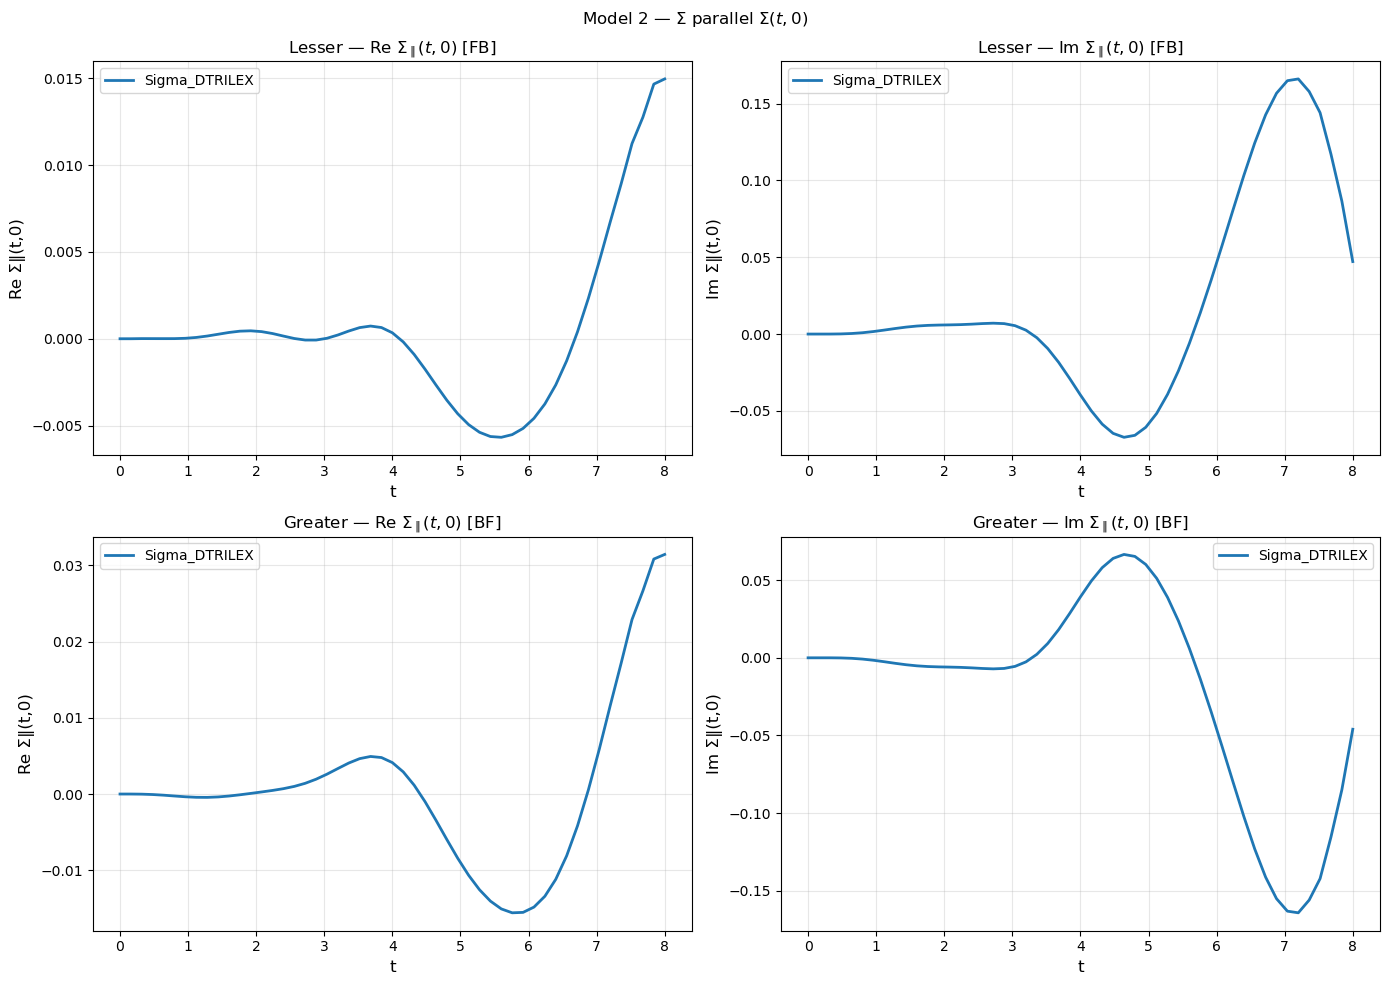

In [14]:
if model == 2:

    # lesser / greater datasets
    components = {
        "Lesser": {
            "suffix": "_par",
            "kcomp": "FB",
        },
        "Greater": {
            "suffix": "_par_greater",
            "kcomp": "BF",
        },
    }

    colors = {
        "Sigma_DTRILEX": "tab:blue",
    }

    linestyles = {
        "Sigma_DTRILEX": "-",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(r"Model 2 — $\Sigma$ parallel $\Sigma(t,0)$")

    for row, (comp_name, comp_info) in enumerate(components.items()):

        suffix = comp_info["suffix"]
        kcomp  = comp_info["kcomp"]

        dat_files = {
            "Sigma_DTRILEX": f"Sigma_Dtrilex{suffix}.dat",
        }

        ax_re = axes[row, 0]
        ax_im = axes[row, 1]

        plot_gf(
            ax_re,
            ax_im,
            dat_files,
            data_dir,
            colors,
            linestyles,
            ylabel="Σ‖(t,0)"
        )

        ax_re.set_title(
            rf"{comp_name} — Re $\Sigma_{{\parallel}}(t,0)$ [{kcomp}]"
        )

        ax_im.set_title(
            rf"{comp_name} — Im $\Sigma_{{\parallel}}(t,0)$ [{kcomp}]"
        )

    plt.tight_layout()

    plots_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        plots_dir / "M2_Sigma_par_2x2.png",
        dpi=150
    )

    plt.show()

else:
    print("Skipping Model 2 Σ‖ plot (model != 2)")

## Perpendicular

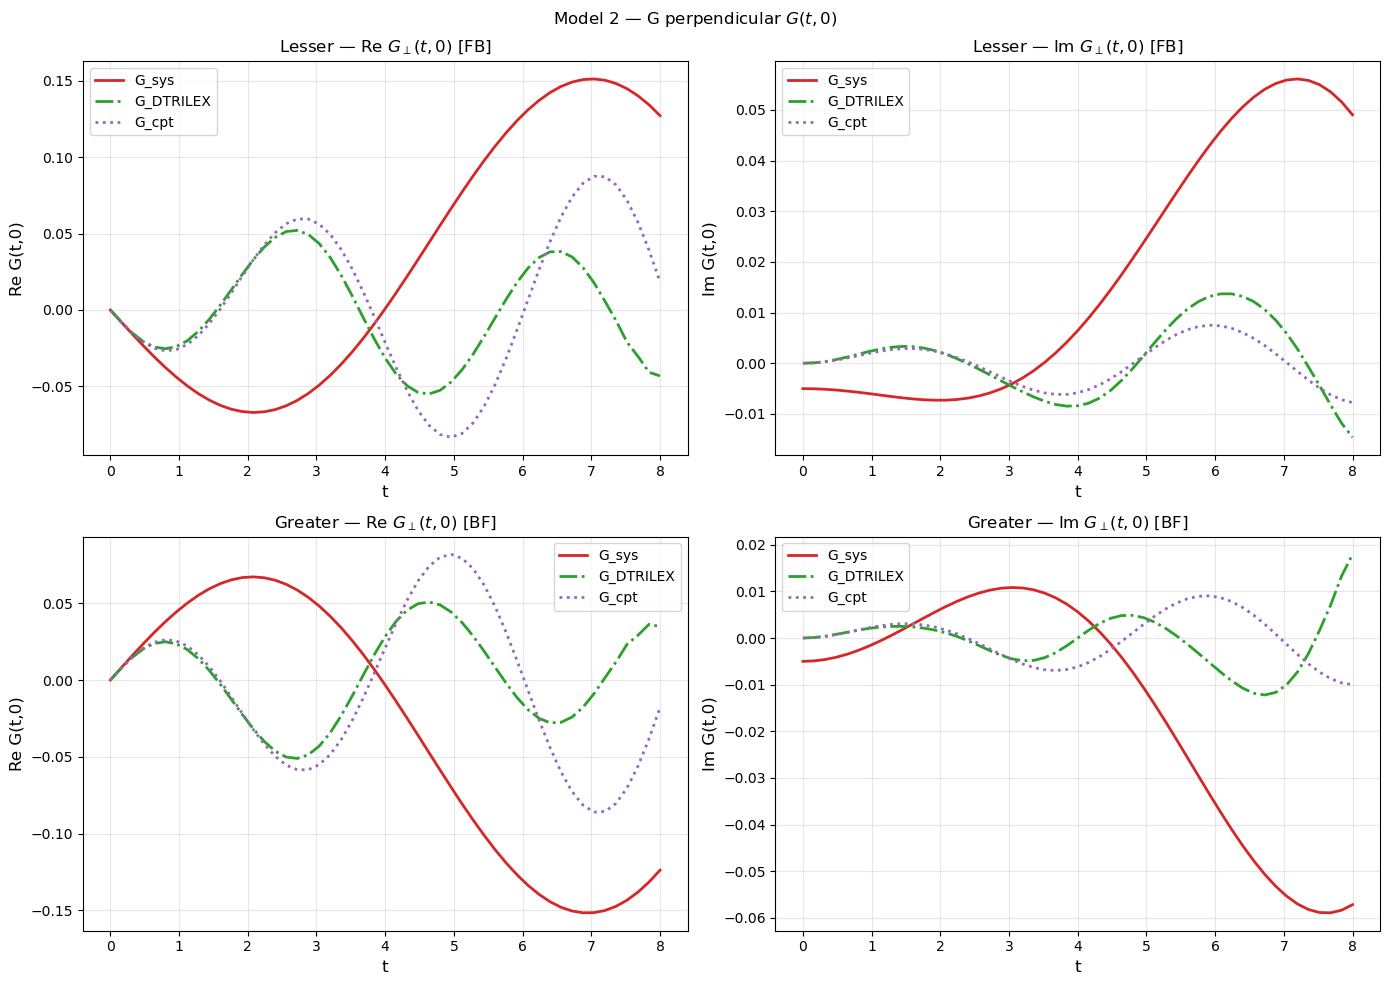

In [15]:
if model == 2:

    # lesser / greater datasets
    components = {
        "Lesser": {
            "suffix": "_perp",
            "kcomp": "FB",
        },
        "Greater": {
            "suffix": "_perp_greater",
            "kcomp": "BF",
        },
    }

    colors = {
        "G_sys":      "tab:red",
        "G_DTRILEX":  "tab:green",
        "G_cpt":      "tab:purple",
    }

    linestyles = {
        "G_sys":      "-",
        "G_DTRILEX":  "-.",
        "G_cpt":      ":",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(r"Model 2 — G perpendicular $G(t,0)$")

    for row, (comp_name, comp_info) in enumerate(components.items()):

        suffix = comp_info["suffix"]
        kcomp  = comp_info["kcomp"]

        dat_files = {
            "G_sys":      f"G_sys{suffix}.dat",
            "G_DTRILEX":  f"G_Dtrilex{suffix}.dat",
            "G_cpt":      f"G_cpt{suffix}.dat",
        }

        ax_re = axes[row, 0]
        ax_im = axes[row, 1]

        plot_gf(
            ax_re,
            ax_im,
            dat_files,
            data_dir,
            colors,
            linestyles
        )

        ax_re.set_title(
            rf"{comp_name} — Re $G_{{\perp}}(t,0)$ [{kcomp}]"
        )

        ax_im.set_title(
            rf"{comp_name} — Im $G_{{\perp}}(t,0)$ [{kcomp}]"
        )

    plt.tight_layout()

    plots_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        plots_dir / "M2_G_perp_2x2.png",
        dpi=150
    )

    plt.show()

else:
    print("Skipping Model 2 G⊥ plot (model != 2)")

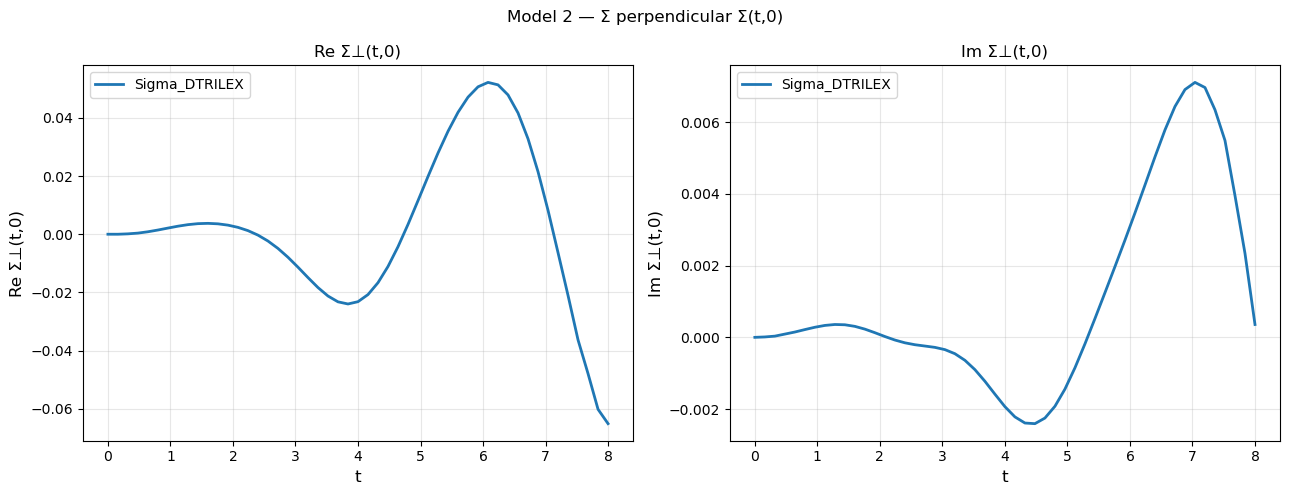

In [ ]:
if model == 2:

    # lesser / greater components (perpendicular)
    components = {
        "Lesser": {
            "suffix": "_perp",
            "kcomp": "FB",
        },
        "Greater": {
            "suffix": "_perp_greater",
            "kcomp": "BF",
        },
    }

    colors = {
        "Sigma_DTRILEX": "tab:blue",
    }

    linestyles = {
        "Sigma_DTRILEX": "-",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(r"Model 2 — Self-energy $\Sigma_{\perp}(t,0)$")

    for row, (comp_name, comp_info) in enumerate(components.items()):

        suffix = comp_info["suffix"]
        kcomp  = comp_info["kcomp"]

        dat_files = {
            "Sigma_DTRILEX": f"Sigma_Dtrilex{suffix}.dat",
        }

        ax_re = axes[row, 0]
        ax_im = axes[row, 1]

        plot_gf(
            ax_re,
            ax_im,
            dat_files,
            data_dir,
            colors,
            linestyles,
            ylabel="Σ⊥(t,0)"
        )

        ax_re.set_title(
            rf"{comp_name} — Re $\Sigma_{{\perp}}(t,0)$ [{kcomp}]"
        )

        ax_im.set_title(
            rf"{comp_name} — Im $\Sigma_{{\perp}}(t,0)$ [{kcomp}]"
        )

    plt.tight_layout()

    plots_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        plots_dir / "M2_Sigma_perp_2x2.png",
        dpi=150
    )

    plt.show()

else:
    print("Skipping Model 2 Σ⊥ plot (model != 2)")